#### Import

In [3]:
from common import *

# Convergence of Metropolis and Gibbs from cold- and hot-start.

#### Setup shared parameters

In [4]:
L = 100

#### Define functions

In [5]:
def plot_convergence(L, T, q, num_samples, step, ax) -> None:
    xs = range(0, num_samples, step)
    pm = PottsModel(L, T, q, Start.Cold)
    energies = pm.sample_metropolis(num_samples)
    ax.plot(xs, energies[::step], label="cold start, Metropolis")

    # hot start, Metropolis
    pm = PottsModel(L, T, q, Start.Hot)
    energies = pm.sample_metropolis(num_samples)
    ax.plot(xs, energies[::step], label="hot start, Metropolis")

    # cold start, Gibbs
    pm = PottsModel(L, T, q, Start.Cold)
    energies = pm.sample_gibbs(num_samples)
    ax.plot(xs, energies[::step], label="cold start, Gibbs")

    # hot start, Gibbs
    pm = PottsModel(L, T, q, Start.Hot)
    energies = pm.sample_gibbs(num_samples)
    ax.plot(xs, energies[::step], label="hot start, Gibbs")

    ax.set_title(rf"$q = {q}$")

#### Run experiment and plot

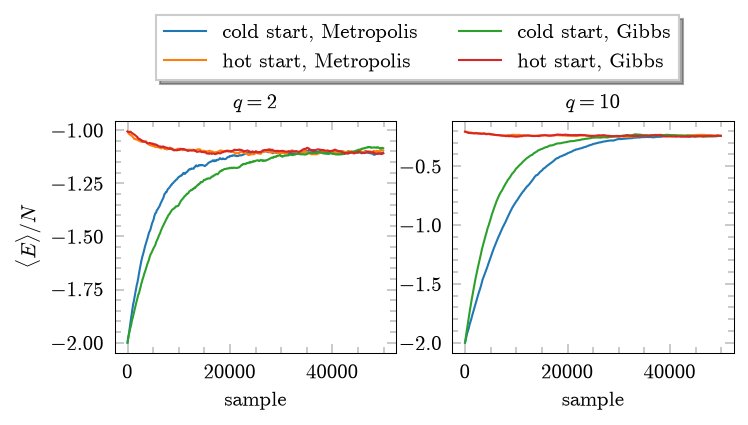

In [6]:
T = 5

num_samples = 50_000
step = 100

fig, ax = plt.subplots(1, 2, figsize=(5,2), dpi=150)

plot_convergence(L, T, 2, num_samples, step, ax=ax[0])
plot_convergence(L, T, 10, num_samples, step, ax=ax[1])

for axis in ax:
    axis.set_xlabel("sample")
ax[0].set_ylabel(r"$\langle E \rangle / N$")


ax[0].legend(loc='upper center', bbox_to_anchor=(1.075, 1.5),
                     ncol=2, fancybox=False, shadow=True)

plt.savefig(FIG_PATH + f"convergence_T={T:.1f}.pdf", bbox_inches='tight', transparent=True, backend='pgf')
plt.show()

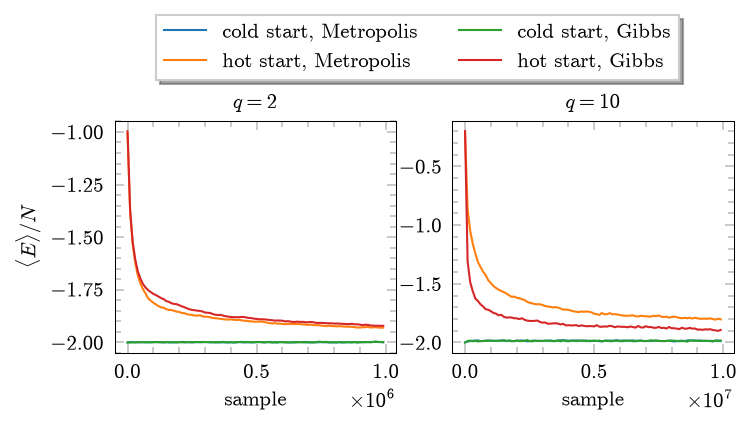

In [7]:
T = 0.5

num_samples = 10_000_000
step = 10_000

fig, ax = plt.subplots(1, 2, figsize=(5,2), dpi=150)

plot_convergence(L, T, 2, 10**6, 10**4, ax=ax[0])
plot_convergence(L, T, 10, 10**7, 10**5, ax=ax[1])

for axis in ax:
    axis.set_xlabel("sample")
ax[0].set_ylabel(r"$\langle E \rangle / N$")

ax[0].legend(loc='upper center', bbox_to_anchor=(1.075, 1.5),
                     ncol=2, fancybox=False, shadow=True)

plt.savefig(FIG_PATH + f"convergence_T={T:.1f}.pdf", bbox_inches='tight', transparent=True, backend='pgf')
plt.show()

# Temperature Dependence of $\langle E \rangle / N$ for $q = 2$ and $q = 10$

#### Setup shared parameters

In [8]:
L = 100
T_min = 0.2
T_max = 2
steps = 50
T_range = np.linspace(T_min, T_max, steps)
q_list = [2, 10]

#### Define functions

In [9]:
def get_mean_std_lists(q: int):
    start_time = time.perf_counter()

    mu_list = []
    sigma_list = []

    pm = PottsModel(L, T_range[0], q, Start.Cold)

    for T in T_range:
        pm.set_temperature(T)
        iterate_until_equilibrium(pm, True)
        energies = pm.sample_metropolis(2**22)
        mu_list.append(np.mean(energies))
        sigma_list.append(batch_means_method(energies))

    end_time = time.perf_counter()
    print(f"Elapsed time: {end_time-start_time:.2f}s (q = {q})")

    return mu_list, sigma_list

#### Run experiment

In [10]:
mp = get_context("fork")
with mp.Pool(len(q_list)) as pool:
    results = list(pool.imap(get_mean_std_lists, q_list))

Elapsed time: 36.62s (q = 2)
Elapsed time: 37.83s (q = 10)


#### Plot

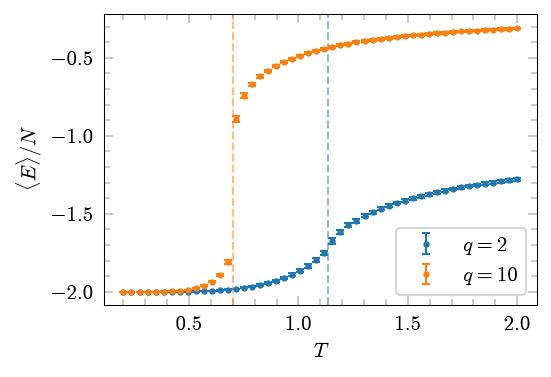

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,2.5), dpi=150)
for q, (E_means, std_list) in zip(q_list, results):
    ebc = ax.errorbar(T_range, E_means, std_list, fmt='.', markersize=4, capsize=2, label=fr"$q={q}$")
    line = ebc.lines[0]
    ax.axvline(x=curie_temp(q),c=line.get_color(), ls='--', alpha=0.5)

ax.set_xlabel(r"$T$")
ax.set_ylabel(r"$\langle E \rangle / N$")

ax.legend()
plt.savefig(FIG_PATH + "temperature_sweep.pdf", bbox_inches='tight', transparent=True, backend='pgf')
plt.show()

# Performance Comparison of Metropolis and Gibbs

#### Setup shared parameters

In [5]:
L = 100

#### Define functions

In [6]:
def plot_convergence(L, T, q, num_metropolis_samples, num_gibbs_samples, step, ax) -> None:
    pm = PottsModel(L, T, q, Start.Cold)
    start_t = time.perf_counter()
    energies = pm.sample_metropolis(num_metropolis_samples)
    total_t = time.perf_counter() - start_t
    times = total_t * np.linspace(0, 1, len(energies))
    ax.plot(times[::step], energies[::step], label="Metropolis")

    pm = PottsModel(L, T, q, Start.Cold)
    start_t = time.perf_counter()
    energies = pm.sample_gibbs(num_gibbs_samples)
    total_t = time.perf_counter() - start_t
    times = total_t * np.linspace(0, 1, len(energies))
    ax.plot(times[::step], energies[::step], label="Gibbs")

    ax.set_title(rf"$q = {q}$")

#### Run Experiments and plot

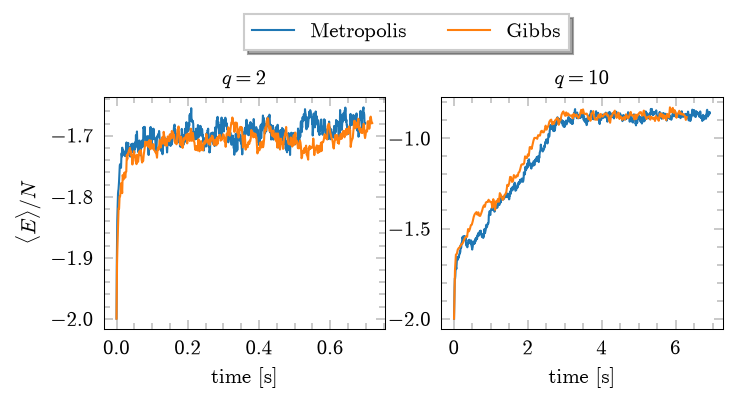

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(5,2), dpi=150)

q = 2
T = curie_temp(q) + 1e-2
plot_convergence(L, T, q, 10**7, 5*10**6, 10**4, ax[0])

q = 10
T = curie_temp(q) + 1e-2
plot_convergence(L, T, q, 10**8, int(2.5*10**7), 10**5, ax[1])

for axis in ax:
    axis.set_xlabel("time [s]")
ax[0].set_ylabel(r"$\langle E \rangle / N$")

ax[0].legend(loc='upper center', bbox_to_anchor=(1.075, 1.4),
                     ncol=2, fancybox=False, shadow=True)

plt.savefig(FIG_PATH + f"thermalization_time_curie.pdf", bbox_inches='tight', transparent=True, backend='pgf')
plt.show()

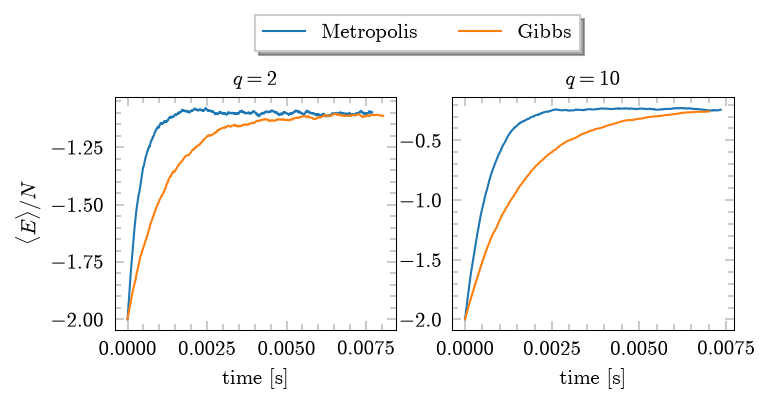

In [9]:

T = 5

fig, ax = plt.subplots(1, 2, figsize=(5,2), dpi=150)

q = 2
plot_convergence(L, T, q, 10**5, 5*10**4, 10**2, ax[0])

q = 10
plot_convergence(L, T, q, 10**5, int(2.5*10**4), 10**2, ax[1])

for axis in ax:
    axis.set_xlabel("time [s]")
ax[0].set_ylabel(r"$\langle E \rangle / N$")

ax[0].legend(loc='upper center', bbox_to_anchor=(1.075, 1.4),
                     ncol=2, fancybox=False, shadow=True)

plt.savefig(FIG_PATH + f"thermalization_time_T={T}.pdf", bbox_inches='tight', transparent=True, backend='pgf')
plt.show()